# Statistical Testing - Correlation, Causation, t-tests, ANOVA

The EDA notebook showed a few relationships that looked interesting - cost vs
release volume, corrosion showing up more on underground pipe, cost varying
by cause category. Here I'm actually testing whether those differences are
statistically significant, and being careful about the correlation vs
causation distinction along the way.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set(style="whitegrid")
plt.style.use('ggplot')

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import warnings
warnings.filterwarnings('ignore')

In [2]:
pipe = pd.read_csv('pipeline-accidents.csv')
pipe['log_cost'] = np.log1p(pipe['All Costs'])
pipe['log_net_loss'] = np.log1p(pipe['Net Loss (Barrels)'])
pipe.shape

(2795, 50)

## 1. Correlation - does a bigger spill mean a bigger cost?

Pearson correlation between `Net Loss (Barrels)` and `All Costs`, plus the
p-value for the null hypothesis that the true correlation is zero.

In [3]:
r, p = stats.pearsonr(pipe['Net Loss (Barrels)'], pipe['All Costs'])
print(f"r = {r:.3f}, p = {p:.4g}")

r = 0.062, p = 0.001055


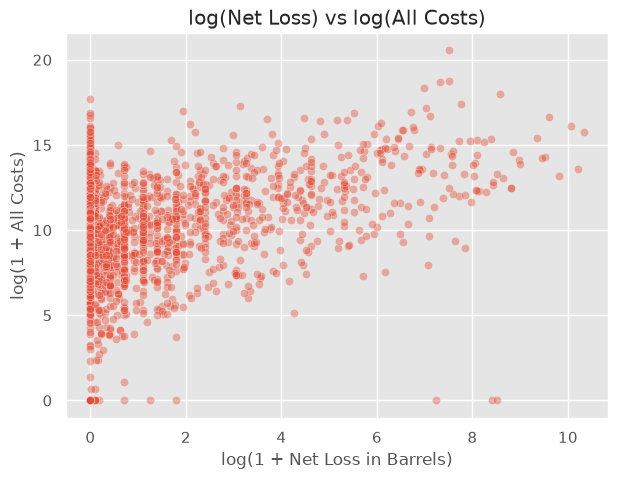

In [4]:
plt.figure(figsize = (7, 5))
sns.scatterplot(x = 'log_net_loss', y = 'log_cost', data = pipe, alpha = 0.4)
plt.title('log(Net Loss) vs log(All Costs)')
plt.xlabel('log(1 + Net Loss in Barrels)')
plt.ylabel('log(1 + All Costs)')
plt.show()

The correlation is statistically significant (p < 0.01) but weak (r ≈ 0.06) on
the raw barrels/dollars scale - a handful of huge outliers are pulling the raw
Pearson number around. Worth noting this is a raw-scale correlation, not
proof that spill size *causes* cost the way it looks in the log-log
scatterplot - other things (pipeline location, cleanup difficulty, whether it
hit a waterway) drive both.

## 2. t-test - aboveground vs underground pipe cost

From the EDA, aboveground and underground accidents looked different in
scale. Testing whether mean `log(All Costs)` actually differs between the two
using Welch's t-test (doesn't assume equal variances).

**H0:** mean log-cost is the same for aboveground and underground accidents.

In [5]:
above = pipe.loc[pipe['Pipeline Type'] == 'ABOVEGROUND', 'log_cost']
under = pipe.loc[pipe['Pipeline Type'] == 'UNDERGROUND', 'log_cost']

t_stat, p_val = stats.ttest_ind(under, above, equal_var = False)
print(f"underground mean log-cost: {under.mean():.2f}")
print(f"aboveground mean log-cost: {above.mean():.2f}")
print(f"t = {t_stat:.2f}, p = {p_val:.4g}")

underground mean log-cost: 11.37
aboveground mean log-cost: 9.06
t = 23.46, p = 7.811e-108


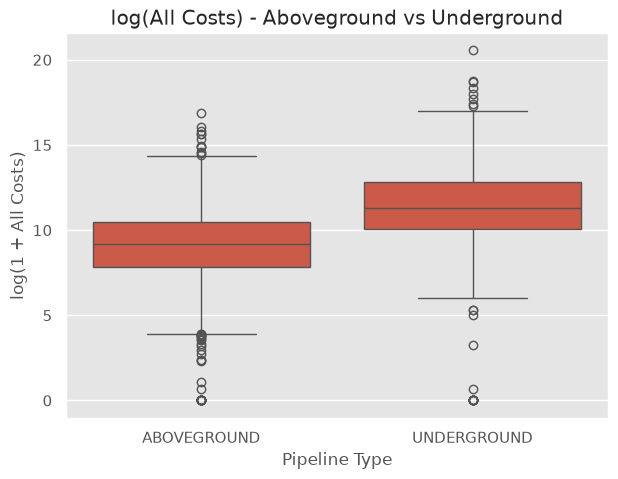

In [6]:
plt.figure(figsize = (7, 5))
sns.boxplot(x = 'Pipeline Type', y = 'log_cost', data = pipe[pipe['Pipeline Type'].isin(['ABOVEGROUND', 'UNDERGROUND'])])
plt.title('log(All Costs) - Aboveground vs Underground')
plt.ylabel('log(1 + All Costs)')
plt.show()

p is way below 0.05, so we reject H0 - underground accidents cost more on
average (makes sense, digging up buried pipe and remediating soil/groundwater
is expensive). Again: pipeline type isn't randomly assigned, so this is an
association, not a controlled experiment.

## 3. ANOVA - does cost vary by cause category?

**H0:** mean log-cost is equal across all `Cause Category` groups.

In [7]:
groups = [g['log_cost'].values for _, g in pipe.groupby('Cause Category')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F = {f_stat:.2f}, p = {p_val:.4g}")

F = 48.30, p = 1.176e-56


In [8]:
# ANOVA assumes normal, equal-variance groups - checking with the non-parametric
# Kruskal-Wallis alternative as a sanity check
h_stat, p_val_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {h_stat:.2f}, p = {p_val_kw:.4g}")

Kruskal-Wallis H = 271.34, p = 1.123e-55


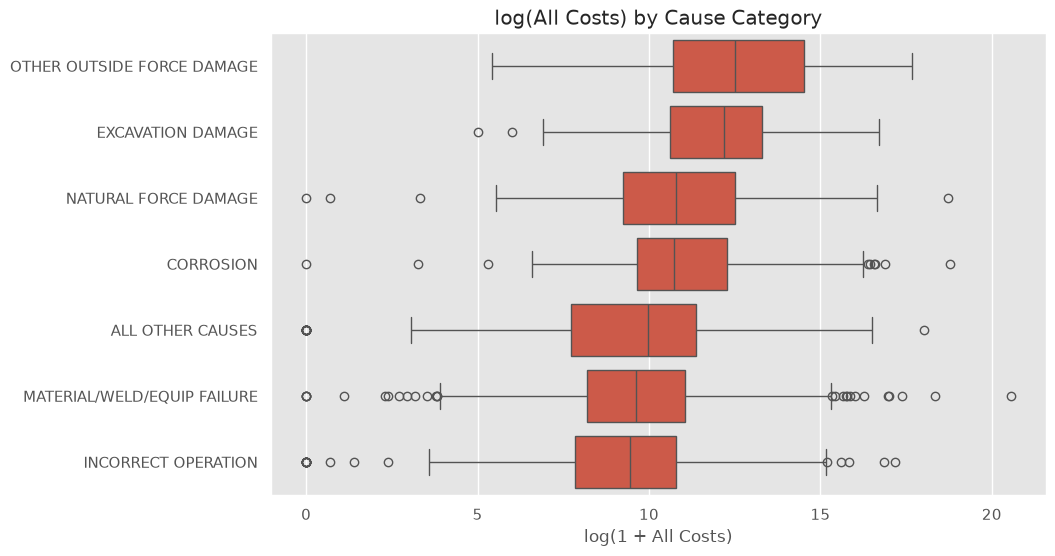

In [9]:
plt.figure(figsize = (10, 6))
order = pipe.groupby('Cause Category')['log_cost'].median().sort_values(ascending = False).index
sns.boxplot(x = 'log_cost', y = 'Cause Category', data = pipe, order = order)
plt.title('log(All Costs) by Cause Category')
plt.xlabel('log(1 + All Costs)')
plt.ylabel('')
plt.show()

Both tests agree - p is essentially 0, so cost really does differ by cause
category. Since ANOVA just says "not all groups are equal" without saying
*which* ones, running Tukey's HSD to see which pairs actually differ.

In [10]:
tukey = pairwise_tukeyhsd(pipe['log_cost'], pipe['Cause Category'])
print(tukey)

                     Multiple Comparison of Means - Tukey HSD, FWER=0.05                      
           group1                      group2           meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------------------------
           ALL OTHER CAUSES                   CORROSION   2.0299    0.0  1.2856  2.7741   True
           ALL OTHER CAUSES           EXCAVATION DAMAGE    2.919    0.0  1.9072  3.9307   True
           ALL OTHER CAUSES         INCORRECT OPERATION   0.2762  0.943 -0.5023  1.0546  False
           ALL OTHER CAUSES MATERIAL/WELD/EQUIP FAILURE   0.7539 0.0278  0.0469  1.4609   True
           ALL OTHER CAUSES        NATURAL FORCE DAMAGE   1.9905    0.0  1.0294  2.9515   True
           ALL OTHER CAUSES  OTHER OUTSIDE FORCE DAMAGE   3.4581    0.0  2.2673  4.6488   True
                  CORROSION           EXCAVATION DAMAGE   0.8891 0.0204  0.0805  1.6977   True
                  CORROSION         INCORRECT OPER

`OTHER OUTSIDE FORCE DAMAGE` and `EXCAVATION DAMAGE` sit at the expensive end, `INCORRECT OPERATION` and `ALL OTHER CAUSES` are cheaper on average, and several pairs (e.g. corrosion vs natural force damage) aren't distinguishable at the 0.05 level - corrosion actually lands in the middle-to-upper range, not with the cheap causes.

## 4. Chi-square - is cause category associated with pipeline type?

Both are categorical, so a t-test/ANOVA doesn't apply - using a chi-square
test of independence on the cause x pipeline-type contingency table instead.

**H0:** `Cause Category` and `Pipeline Type` are independent.

In [11]:
cause_pipe = pd.crosstab(pipe['Cause Category'], pipe['Pipeline Type'])
chi2, p_val, dof, expected = stats.chi2_contingency(cause_pipe)
print(f"chi2 = {chi2:.1f}, dof = {dof}, p = {p_val:.4g}")

chi2 = 787.8, dof = 18, p = 1.237e-155


p is essentially 0 - cause category and pipeline type are not independent, which matches what the heatmap in the EDA notebook showed (corrosion skews underground, other causes skew aboveground/tank).

In [12]:
cause_liquid = pd.crosstab(pipe['Cause Category'], pipe['Liquid Type'])
chi2b, p_val_b, dof_b, expected_b = stats.chi2_contingency(cause_liquid)
print(f"chi2 = {chi2b:.1f}, dof = {dof_b}, p = {p_val_b:.4g}")

chi2 = 179.0, dof = 24, p = 1.136e-25


Same story for cause category vs liquid type - also significant.

## Correlation vs causation - the caveat

Every test above is describing *association* in observational data, not a
controlled experiment:

- None of the group memberships here (pipeline type, cause category, liquid
  type) were randomly assigned - operators chose where to build aboveground
  vs underground, which liquids to carry, etc. Any of those choices could be
  correlated with confounders (pipeline age, region, operator safety
  practices) that are the *real* driver of cost.
- With this many tests run back to back, some "significant" results are
  expected by chance alone (multiple comparisons) - the Tukey HSD step above
  already corrects for that within the ANOVA follow-up, but the four main
  tests earlier in this notebook don't have a joint correction applied.
- A small p-value tells us an effect probably isn't zero, not that it's
  large or practically important - the r ≈ 0.06 correlation in section 1 is
  a good example: significant, but weak.

None of that makes these tests useless - they're a legitimate way to confirm
what the EDA plots suggested is unlikely to be pure noise. It just means
"cause category is associated with cost" is a fair conclusion; "cause
category causes higher cost" is not, without a causal design to back it up.